In [1]:
from music21 import stream, note, meter, key
from collections import defaultdict
import os
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random


In [2]:
with open('rhythm_dict/rhythm_dict_with_cleanup_20dec25.pkl', 'rb') as f:
    rhythm_dict = pickle.load(f)

with open('markov_dict/pitch_markov_restrictedG3E6.pkl', 'rb') as f:
    pitch_markov_prob = pickle.load(f)

In [ ]:


# --------------------------------
# SETTINGS
# --------------------------------

ALLOWED_NOTES = {60, 62, 64, 65, 67}  # C4 D4 E4 F4 G4
CADENCES = {2: 67, 4: 60}             # Bar 2 -> G, Bar 4 -> C
ALLOWED_DURATIONS = {1.0, 0.5, 2.0}


KEY_SETTINGS = {
    "C_major": {
        "notes": {60,62,64,65,67},
        "cadences": {2:67,4:60},
        "start": [60,64,67]
    },
    "D_minor": {
        "notes": {62,64,65,67,69,70,72},
        "cadences": {2:69,4:62},
        "start": [62,65,69]
    }
}

# ===============================
# UTILITY FUNCTIONS
# ===============================

def normalize(weight_dict):
    total = sum(weight_dict.values())
    if total == 0:
        return {}
    return {k: v / total for k, v in weight_dict.items()}

def weighted_sample(prob_dict):
    if not prob_dict:
        return None
    items = list(prob_dict.keys())
    weights = list(prob_dict.values())
    return random.choices(items, weights=weights, k=1)[0]

# ===============================
# RHYTHM FILTER
# ===============================

def is_initial_rhythm(pattern):
    if abs(sum(pattern) - 4.0) > 1e-6:
        return False
    return all(d in ALLOWED_DURATIONS for d in pattern)

def get_initial_rhythms(rhythm_dict):
    patterns = rhythm_dict.get("4/4", {})
    return {
        p: c
        for p, c in patterns.items()
        if is_initial_rhythm(p)
    }

def sample_rhythm(initial_rhythms):
    probs = normalize(initial_rhythms)
    return weighted_sample(probs)

# ===============================
# MARKOV CONSTRAINTS
# ===============================

def constrained_transitions(prev_note, pitch_markov_prob):
    raw = pitch_markov_prob.get(prev_note, {})
    filtered = {}

    for nxt, prob in raw.items():
        if nxt in ALLOWED_NOTES and abs(nxt - prev_note) <= 4:
            filtered[nxt] = prob

    # fallback if empty
    if not filtered:
        for candidate in ALLOWED_NOTES:
            if abs(candidate - prev_note) <= 2:
                filtered[candidate] = 1.0

    return filtered

def pedagogical_bias(prev_note, candidates, bar_number):
    for nxt in list(candidates.keys()):
        # Stepwise boost
        if abs(nxt - prev_note) <= 2:
            candidates[nxt] *= 1.5 #to encourage steps up to 2 semitones

        # Phrase direction
        if bar_number <= 2 and nxt > prev_note:
            candidates[nxt] *= 1.2
        if bar_number > 2 and nxt < prev_note:
            candidates[nxt] *= 1.2

    return candidates

# ===============================
# BAR GENERATION
# ===============================

def generate_bar(prev_note, bar_number, rhythm, pitch_markov_prob):

    bar_notes = []

    for dur in rhythm:

        candidates = constrained_transitions(prev_note, pitch_markov_prob)
        candidates = pedagogical_bias(prev_note, candidates, bar_number)
        candidates = normalize(candidates)

        next_note = weighted_sample(candidates)

        if next_note is None:
            next_note = random.choice(list(ALLOWED_NOTES))

        bar_notes.append((next_note, dur))
        prev_note = next_note

    # enforce cadence
    if bar_number in CADENCES:
        target = CADENCES[bar_number]
        bar_notes[-1] = (target, bar_notes[-1][1])
        prev_note = target

    return bar_notes, prev_note

# ===============================
# FULL EXERCISE GENERATOR
# ===============================

def generate_exercise(pitch_markov_prob, rhythm_dict):

    initial_rhythms = get_initial_rhythms(rhythm_dict)

    if not initial_rhythms:
        raise ValueError("No valid Initial-grade rhythms found.")

    exercise = []
    prev_note = random.choice([60, 64, 67])  # start stable

    for bar_number in range(1, 5):

        rhythm = sample_rhythm(initial_rhythms)
        bar, prev_note = generate_bar(
            prev_note,
            bar_number,
            rhythm,
            pitch_markov_prob
        )

        exercise.append(bar)

    return exercise

# ===============================
# RENDER WITH MUSIC21
# ===============================

def render_exercise(exercise):
    print(exercise)

    score = stream.Score()
    part = stream.Part()

    part.append(key.Key("C"))
    part.append(meter.TimeSignature("4/4"))

    for bar_data in exercise:
        m = stream.Measure()
        for midi_pitch, dur in bar_data:
            n = note.Note()
            n.pitch.midi = midi_pitch
            n.quarterLength = dur
            m.append(n)
        part.append(m)

    score.append(part)
    score.show()

[[(67, 1.0), (67, 1.0), (67, 1.0), (65, 0.5), (67, 0.5)], [(65, 1.0), (62, 2.0), (67, 1.0)], [(65, 0.5), (64, 0.5), (65, 1.0), (67, 2.0)], [(67, 0.5), (67, 0.5), (65, 1.0), (60, 2.0)]]


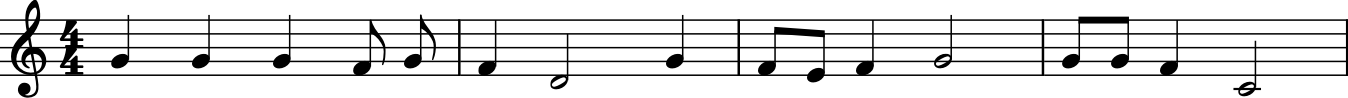

In [14]:
exercise = generate_exercise(pitch_markov_prob, rhythm_dict)
render_exercise(exercise)